# 3D 복셀 입력 만들기 — 단계별 해석 노트북

`src/build_voxel_v2.py`(복셀 생성)와, 그 안에서 불러 쓰는 `src/voxelize_mmp.py`의 `build_aligned_pair`(3D 정렬), `src/qm_esp.py`(양자화학 ESP), `src/render_v2.py`(3D 렌더)의 흐름을 **한 단계씩 풀어서** 실행하고 단계마다 중간 결과를 눈으로 확인한다.

| 단계 | 하는 일 | 원본 코드 |
|---|---|---|
| 0 | 환경 준비 | — |
| 1 | 분자 쌍(SMILES) 정하기 | `build_voxel_v2.py:63` `PAIRS` |
| 2 | 공통 부분구조(MCS) 찾기 | `voxelize_mmp.py:125` |
| 3 | 3D 구조(conformer) 만들기 | `voxelize_mmp.py:105` `embed` |
| 4 | B 를 A 에 겹치기 (정렬) | `voxelize_mmp.py:115` `build_aligned_pair` |
| 5 | 3D 격자 만들기 | `build_voxel_v2.py:88` `grid_coords` |
| 6 | 원자 채널 6개 | `build_voxel_v2.py:100` `base_channels` |
| 7 | 결합 채널 4개 | `build_voxel_v2.py:100` `base_channels` |
| 8 | ESP 채널 1개 — 8-1 점전하 근사(비교용), 8-2 양자화학 DFT(채널에 사용) | `build_voxel_v2.py:133` `esp_channel`, `qm_esp.py` |
| 9 | 편집 종류 a 판정 | `build_voxel_v2.py:72` `action_type` |
| 10 | 모델 입력 (X_s, X_s′, a) 조립 | `build_voxel_v2.py:174` `featurize` |
| 11 | 3D 렌더링 | `render_v2.py` |
| 12 | 원본 코드와 결과 일치 확인 | — |

전체 흐름

```
SMILES 2개 ─▶ MCS ─▶ 3D 구조 ─▶ MCS 정렬 ─▶ 48³ 격자 ─▶ 원자 6 + 결합 4 + ESP 1 채널 ─▶ (X_s, X_s′, a) ─▶ [3D CNN → ΔpKi : 미구현]
```

> 이 노트북은 **모델 입력을 만드는 데까지**만 다룬다. 3D CNN 학습과 실측 라벨(ΔpKi) 연결은 아직 구현되지 않았다 (`docs/입력구조_v2.md` 상태 메모와 같음).
>
> 커널은 **Python (capstone)** 을 고른다 (VS Code 오른쪽 위 *Select Kernel*).

## 0. 환경 준비

- 필요한 라이브러리, 한글 폰트, 재현용 시드를 준비한다.
- 1–11단계는 원본 함수를 부르지 않고 **같은 계산을 셀 안에 직접 풀어 쓴다.** `src/` 를 import 경로에 넣는 것은 12단계에서 원본과 결과를 비교하기 위해서다.

In [4]:
import os, sys, warnings
from pathlib import Path

os.environ.setdefault("EGL_LOG_LEVEL", "fatal")    # 리눅스 서버에서 3D 렌더 시 경고 메시지 숨김

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Draw, rdFMCS, rdMolAlign
from rdkit.Chem.Draw import IPythonConsole

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

# 한글 폰트 — 맥: AppleGothic / 리눅스 서버: Noto Sans CJK (JP 이름이지만 한글 글리프 포함)
have = {f.name for f in font_manager.fontManager.ttflist}
for cand in ("AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "Noto Sans CJK JP",
             "NanumGothic", "Malgun Gothic"):
    if cand in have:
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False

SEED = 0xC11FF   # 원본(voxelize_mmp.py)과 같은 시드 → 같은 3D 구조가 나온다
print("프로젝트 폴더:", ROOT)
print("폰트:", plt.rcParams["font.family"])

프로젝트 폴더: /home/dlrudgms1211/캡스톤 프로젝트
폰트: ['Noto Sans CJK JP']


## 1. 분자 쌍 정하기

- 모델은 "한 곳만 다른 두 분자" **A (= s, 입력 상태)** 와 **B (= s′, 결과 상태)** 를 받는다.
- SMILES 는 분자를 한 줄 문자로 적는 표기법이다. 예: `CC(=O)Nc1ccc(F)cc1` = 4-플루오로아세트아닐라이드 (벤젠 고리 `c1ccc...cc1` 에 아마이드와 F 가 붙음).
- 원본의 예시 4쌍 중 하나를 고른다. **`PICK` 만 바꾸고 위에서부터 다시 실행하면 모든 단계가 그 쌍으로 계산된다.**

A (s)  : CC(=O)Nc1ccc(F)cc1           무거운 원자 11개
B (s′) : CC(=O)Nc1ccc(N)cc1           무거운 원자 11개


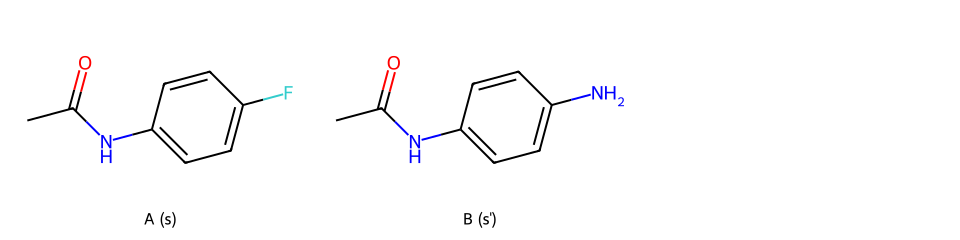

In [5]:
PAIRS = {   # build_voxel_v2.py 의 PAIRS 와 같은 4쌍
    "01_F_to_NH2":       ("CC(=O)Nc1ccc(F)cc1",       "CC(=O)Nc1ccc(N)cc1"),
    "02_ring5_to_ring6": ("CC(=O)Nc1ccc(N2CCCC2)cc1", "CC(=O)Nc1ccc(N2CCCCC2)cc1"),
    "03_H_to_phenyl":    ("CC(=O)Nc1ccccc1",          "CC(=O)Nc1ccc(-c2ccccc2)cc1"),
    "04_OMe_to_H":       ("CC(=O)Nc1ccc(OC)cc1",      "CC(=O)Nc1ccccc1"),
}
PICK = "01_F_to_NH2"

smi_a, smi_b = PAIRS[PICK]
mol_a = Chem.MolFromSmiles(smi_a)
mol_b = Chem.MolFromSmiles(smi_b)
print(f"A (s)  : {smi_a:28s} 무거운 원자 {mol_a.GetNumAtoms()}개")
print(f"B (s′) : {smi_b:28s} 무거운 원자 {mol_b.GetNumAtoms()}개")
Draw.MolsToGridImage([mol_a, mol_b], legends=["A (s)", "B (s')"], subImgSize=(320, 240))

## 2. 공통 부분구조(MCS) 찾기

- **MCS (Maximum Common Substructure)** = 두 분자가 똑같이 가진 가장 큰 조각. 이 조각이 "골격(scaffold)", 나머지가 **편집 부위**(바뀐 곳)다.
- 옵션의 뜻
  - `completeRingsOnly=True` — 고리는 통째로만 공통으로 인정 (고리 일부만 겹치는 것 금지)
  - `ringMatchesRingOnly=True` — 고리 원자는 고리 원자하고만 짝지음
  - `CompareElements` / `CompareOrder` — 원소 종류와 결합 차수가 같아야 같은 것으로 봄
- 그림에서 **색칠된 원자 = MCS(공통 골격)**, 색이 없는 원자 = 편집 부위.
- 참고: `02_ring5_to_ring6` 은 원자 1개만 늘어난 것처럼 보이지만, `completeRingsOnly` 때문에 고리 전체가 MCS 밖으로 빠진다 → 9단계에서 Replace 로 판정된다.

MCS 원자 10개, 결합 10개
MCS SMARTS: [#6&!R]-&!@[#6&!R](=&!@[#8&!R])-&!@[#7&!R]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
A 에서 MCS 밖 원자: ['F8']
B 에서 MCS 밖 원자: ['N8']


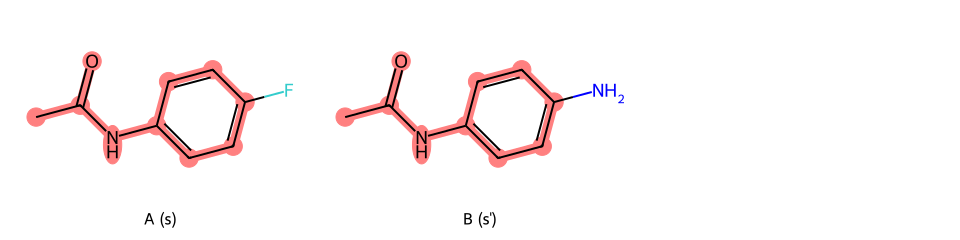

In [6]:
mcs = rdFMCS.FindMCS(
    [mol_a, mol_b],
    completeRingsOnly=True,
    ringMatchesRingOnly=True,
    atomCompare=rdFMCS.AtomCompare.CompareElements,
    bondCompare=rdFMCS.BondCompare.CompareOrder,
    timeout=20,
)
patt = Chem.MolFromSmarts(mcs.smartsString)    # MCS 를 검색용 패턴으로 변환
print(f"MCS 원자 {mcs.numAtoms}개, 결합 {mcs.numBonds}개")
print("MCS SMARTS:", mcs.smartsString)

hit_a = mol_a.GetSubstructMatch(patt)
hit_b = mol_b.GetSubstructMatch(patt)
label = lambda m, i: f"{m.GetAtomWithIdx(i).GetSymbol()}{i}"
print("A 에서 MCS 밖 원자:", [label(mol_a, i) for i in range(mol_a.GetNumAtoms()) if i not in hit_a])
print("B 에서 MCS 밖 원자:", [label(mol_b, i) for i in range(mol_b.GetNumAtoms()) if i not in hit_b])
Draw.MolsToGridImage([mol_a, mol_b], legends=["A (s)", "B (s')"], subImgSize=(320, 240),
                     highlightAtomLists=[list(hit_a), list(hit_b)])

## 3. 3D 구조(conformer) 만들기

SMILES 에는 좌표가 없다. 격자에 넣으려면 원자들의 3D 위치(conformer)를 만들어야 한다. (`voxelize_mmp.py:105` `embed`)

1. `AddHs` — 수소를 붙인다. 수소 없이 3D 를 만들면 결합 각도·거리가 틀어진다.
2. `ETKDGv3` — 결합 길이·각도 규칙과 실험 구조 통계로 초기 3D 좌표를 만든다. `randomSeed` 를 고정해 매번 같은 구조가 나오게 한다.
3. `MMFFOptimizeMolecule` — MMFF94 힘장(force field)으로 에너지를 낮춰 구조를 다듬는다.
4. `RemoveHs` — 수소를 다시 뗀다. 원자·결합 채널은 **무거운 원자만** 쓴다. (ESP 채널을 만드는 8단계에서 수소를 다시 붙인다.)

In [7]:
def embed(mol, seed=SEED):
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    if AllChem.EmbedMolecule(mol, params) != 0:
        raise RuntimeError("conformer 생성 실패")
    AllChem.MMFFOptimizeMolecule(mol, maxIters=500)
    return Chem.RemoveHs(mol)

def positions(mol):
    """원자 좌표 (원자 수, 3), 단위 Å"""
    conf = mol.GetConformer()
    return np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])

a3 = embed(mol_a)
b3 = embed(mol_b)
print("분자 A 의 3D 좌표 (단위 Å)")
pd.DataFrame(positions(a3), columns=["x", "y", "z"],
             index=[label(a3, i) for i in range(a3.GetNumAtoms())]).round(2).T

분자 A 의 3D 좌표 (단위 Å)


,C0,C1,O2,N3,C4,C5,C6,C7,F8,C9,C10
x,3.44,1.99,1.67,1.14,-0.27,-1.05,-2.44,-3.06,-4.40,-2.31,-0.91
y,0.23,0.37,0.80,-0.06,-0.08,0.37,0.32,-0.18,-0.23,-0.63,-0.58
z,0.73,1.11,2.21,0.11,0.12,1.19,1.13,-0.01,-0.07,-1.09,-1.02


## 4. B 를 A 에 겹치기 (MCS 정렬)

- A 와 B 를 따로 3D 로 만들면 서로 다른 위치·방향에 놓인다. 그대로 격자에 넣으면 **골격까지 전부 다르게 보여서** 모델이 "어디가 바뀌었는지" 알 수 없다.
- 그래서 MCS(공통 골격) 원자끼리 최대한 겹치도록 B 를 옮기고 돌린다. 겹친 정도는 **MCS RMSD** (짝지은 공통 원자 사이 거리의 제곱평균제곱근, Å) 로 잰다. 작을수록 잘 겹친 것이다.
- 원본의 전략 (`voxelize_mmp.py:115` `build_aligned_pair`)
  1. B 의 conformer 를 시드를 바꿔 10개 만들고, 각각 A 에 **강체 정렬**(`AlignMol`, 회전+이동만) 한 뒤 RMSD 가 가장 작은 것을 고른다. 한 번만 뽑으면 골격이 크게 어긋날 수 있어서다.
  2. 그래도 RMSD 가 0.10 Å 보다 크면, A 의 골격 좌표를 고정한 채 B 를 새로 만든다 (`ConstrainedEmbed`). 그쪽이 더 작으면 교체.

In [8]:
N_CONF, RMSD_TOL = 10, 0.10

ma = a3.GetSubstructMatch(patt)   # A 의 MCS 원자 번호들
mb = b3.GetSubstructMatch(patt)   # B 의 MCS 원자 번호들 (ma 와 같은 순서로 짝지어짐)

def mcs_rmsd(mol_b, match_b):
    pa_ = positions(a3)[list(ma)]
    pb_ = positions(mol_b)[list(match_b)]
    return float(np.sqrt(((pa_ - pb_) ** 2).sum(-1).mean()))

print(f"정렬 전 MCS RMSD: {mcs_rmsd(b3, mb):.3f} Å  (A, B 가 서로 다른 곳에 놓여 있음)")

# 1) 첫 conformer(시드 SEED) 를 A 에 정렬
rdMolAlign.AlignMol(b3, a3, atomMap=list(zip(mb, ma)))
best_rmsd = mcs_rmsd(b3, mb)
strategy = f"AlignMol×{N_CONF}"
log = [(0, SEED, best_rmsd)]

# 1') 시드를 바꿔 9개 더 만들고, 가장 잘 겹치는 것을 고른다
for k in range(1, N_CONF):
    try:
        cand = embed(mol_b, seed=SEED + 7919 * k)
        mcand = cand.GetSubstructMatch(patt)
        if not mcand or len(mcand) != len(ma):
            continue
        rdMolAlign.AlignMol(cand, a3, atomMap=list(zip(mcand, ma)))
        r = mcs_rmsd(cand, mcand)
        log.append((k, SEED + 7919 * k, r))
        if r < best_rmsd:
            b3, mb, best_rmsd = cand, mcand, r
    except Exception:
        continue

pd.DataFrame(log, columns=["후보 k", "시드", "정렬 후 MCS RMSD (Å)"]).set_index("후보 k").round(4)

정렬 전 MCS RMSD: 1.611 Å  (A, B 가 서로 다른 곳에 놓여 있음)


,시드,정렬 후 MCS RMSD (Å)
후보 k,,
0,791039,1.1314
1,798958,1.1314
2,806877,1.1327
3,814796,1.1325
4,822715,0.0351
5,830634,1.1314
6,838553,1.1325
7,846472,1.1327
8,854391,0.0216


In [9]:
# 2) 그래도 어긋나 있으면 골격 고정 임베딩(ConstrainedEmbed) 시도
print(f"10개 후보 중 최소 RMSD: {best_rmsd:.4f} Å   (기준 {RMSD_TOL} Å)")
if best_rmsd > RMSD_TOL:
    try:
        core = Chem.RWMol(patt)
        conf = Chem.Conformer(core.GetNumAtoms())
        for i, ai in enumerate(ma):                       # 골격 좌표 = A 의 MCS 좌표
            conf.SetAtomPosition(i, a3.GetConformer().GetAtomPosition(ai))
        core.RemoveAllConformers()
        core.AddConformer(conf)
        cb = AllChem.ConstrainedEmbed(Chem.AddHs(mol_b), core.GetMol(), randomseed=SEED)
        cb = Chem.RemoveHs(cb)
        mcb = cb.GetSubstructMatch(patt)
        rdMolAlign.AlignMol(cb, a3, atomMap=list(zip(mcb, ma)))
        r = mcs_rmsd(cb, mcb)
        print(f"ConstrainedEmbed RMSD: {r:.4f} Å")
        if r < best_rmsd:
            b3, mb, best_rmsd, strategy = cb, mcb, r, "ConstrainedEmbed"
    except Exception as e:
        print("ConstrainedEmbed 실패:", e)
else:
    print("→ 이미 충분히 겹침. ConstrainedEmbed 생략")
print(f"최종 정렬: {strategy},  MCS RMSD {best_rmsd:.4f} Å")

10개 후보 중 최소 RMSD: 0.0216 Å   (기준 0.1 Å)
→ 이미 충분히 겹침. ConstrainedEmbed 생략
최종 정렬: AlignMol×10,  MCS RMSD 0.0216 Å


정렬 결과를 3D 로 확인한다. **회색 = A, 청록 = B**, 빨간 원 = 편집 원자(MCS 밖). 골격은 두 색이 거의 포개지고, 편집 부위만 달라야 정상이다.

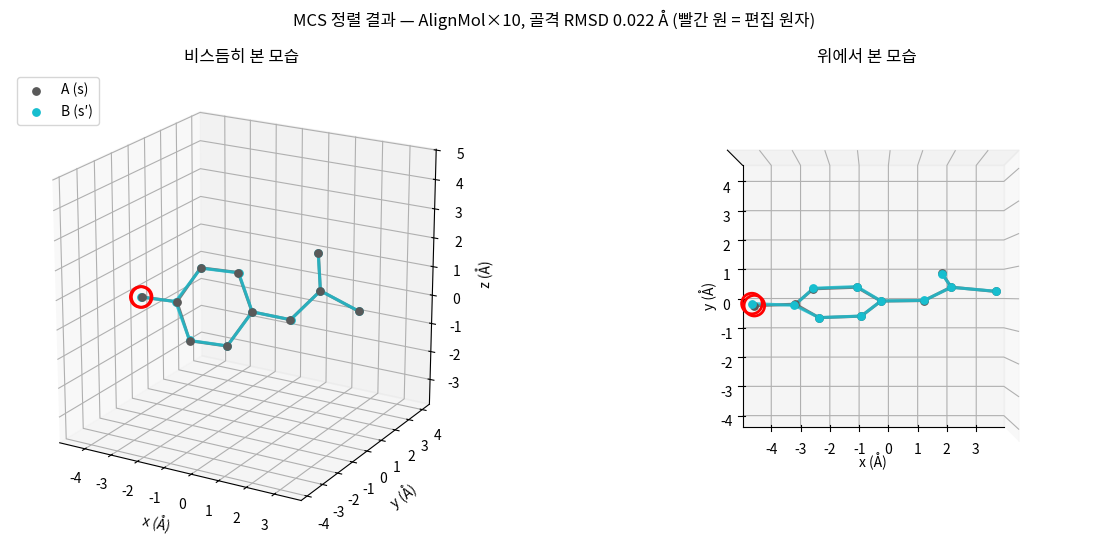

In [10]:
edit_a = [i for i in range(a3.GetNumAtoms()) if i not in set(ma)]
edit_b = [i for i in range(b3.GetNumAtoms()) if i not in set(mb)]
allp = np.vstack([positions(a3), positions(b3)])
mid, half = (allp.min(0) + allp.max(0)) / 2, (allp.max(0) - allp.min(0)).max() / 2 + 0.5

fig = plt.figure(figsize=(13, 5.5))
for n, (elev, azim, title) in enumerate([(20, -60, "비스듬히 본 모습"), (90, -90, "위에서 본 모습")]):
    ax = fig.add_subplot(1, 2, n + 1, projection="3d")
    for mol, color, edit, name in ((a3, "0.35", edit_a, "A (s)"), (b3, "tab:cyan", edit_b, "B (s′)")):
        p = positions(mol)
        for bd in mol.GetBonds():
            ax.plot(*p[[bd.GetBeginAtomIdx(), bd.GetEndAtomIdx()]].T, color=color, lw=2.2, alpha=0.8)
        ax.scatter(*p.T, color=color, s=28, depthshade=False, label=name)
        if edit:
            ax.scatter(*p[edit].T, s=220, facecolors="none", edgecolors="red", linewidths=2)
    for d, setlim in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setlim(mid[d] - half, mid[d] + half)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)")
    if n == 0:
        ax.set_zlabel("z (Å)")
    else:
        ax.set_zticks([])
    ax.set_title(title)
    if n == 0:
        ax.legend(loc="upper left")
fig.suptitle(f"MCS 정렬 결과 — {strategy}, 골격 RMSD {best_rmsd:.3f} Å (빨간 원 = 편집 원자)")
plt.tight_layout(); plt.show()

(선택) 마우스로 돌려 보고 싶으면 아래 셀을 실행한다. 3Dmol.js 를 인터넷에서 불러오므로 화면이 비어 있으면 셀을 다시 실행한다.

In [11]:
import py3Dmol
view = py3Dmol.view(width=700, height=400)
view.addModel(Chem.MolToMolBlock(a3), "mol")
view.setStyle({"model": 0}, {"stick": {"colorscheme": "grayCarbon", "radius": 0.16}})
view.addModel(Chem.MolToMolBlock(b3), "mol")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.10, "opacity": 0.85}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. 3D 격자 만들기

- 한 변 24 Å 정육면체를 0.5 Å 간격으로 나누면 한 축에 24 / 0.5 = **48칸**, 전체 48³ = 110,592칸(복셀, voxel)이다.
- 격자 중심 = A 와 B 의 무거운 원자를 모두 감싸는 상자(bounding box)의 중심.
- **A 와 B 는 같은 격자를 쓴다.** 그래야 같은 칸이 같은 공간 위치를 뜻하고, 두 격자를 칸끼리 비교할 수 있다.
- 분자 + vdW 반지름(최대 약 1.7 Å) + ESP 셸 두께가 박스 절반(12 Å)을 넘으면 가장자리가 잘릴 수 있어 확인한다.
- `pts[i, j, k]` = (i, j, k) 번째 칸 **중심**의 실제 좌표 (x, y, z).

In [12]:
BOX_A, RES_A = 24.0, 0.5
N = int(round(BOX_A / RES_A))          # 48
SIGMA_SURF = 0.40                      # ESP 셸 두께 (8단계에서 사용)

pa, pb = positions(a3), positions(b3)
both = np.vstack([pa, pb])
center = (both.min(0) + both.max(0)) / 2
reach = float(np.abs(both - center).max()) + 1.7 + 2 * SIGMA_SURF
print(f"격자 {N}×{N}×{N} = {N**3:,}칸,  중심 {center.round(2)} Å")
print(f"분자가 닿는 최대 거리 {reach:.1f} Å  vs  박스 절반 {BOX_A / 2:.1f} Å  →",
      "OK" if reach <= BOX_A / 2 else "⚠️ 박스 밖으로 잘릴 수 있음")

def grid_coords(center):
    lo = center - BOX_A / 2 + RES_A / 2               # 첫 칸의 중심
    ax = [lo[d] + RES_A * np.arange(N) for d in range(3)]
    return np.stack(np.meshgrid(*ax, indexing="ij"), axis=-1)

pts = grid_coords(center)
print("pts 모양:", pts.shape, "  = (48, 48, 48, xyz)")
print("첫 칸 중심:", pts[0, 0, 0].round(2), "   마지막 칸 중심:", pts[-1, -1, -1].round(2))

격자 48×48×48 = 110,592칸,  중심 [-0.52  0.09  0.57] Å
분자가 닿는 최대 거리 6.5 Å  vs  박스 절반 12.0 Å  → OK
pts 모양: (48, 48, 48, 3)   = (48, 48, 48, xyz)
첫 칸 중심: [-12.27 -11.66 -11.18]    마지막 칸 중심: [11.23 11.84 12.32]


## 6. 원자 채널 6개 (C, N, O, S, 할로겐, 기타)

- 원자 하나를 **가우시안 구름**으로 칠한다. 칸 중심과 원자 사이 거리가 d 일 때 값 = exp(−d² / 2σ²), σ = 0.45 Å.
  - 원자 바로 위 칸 ≈ 1, 0.45 Å 떨어지면 0.61, 1 Å 떨어지면 0.08 → 원자가 **작은 공**처럼 보인다.
- 원소마다 다른 채널에 넣는다 (`voxelize_mmp.py:47` `atom_channel`). 같은 채널 원자끼리는 **더한다(sum)**.
- 왜 원소별로 채널을 나누나: 한 채널에 다 넣으면 "여기 원자가 있다"만 알고 "무슨 원자인지"는 모른다. 컬러 이미지의 RGB 채널처럼, 채널이 원소 정보를 담는다.

In [13]:
ATOM_CHANNELS = ["C", "N", "O", "S", "할로겐", "기타"]
SIGMA_ATOM = 0.45

def atom_channel(atom):
    # 원자번호 → 채널: C 6→0, N 7→1, O 8→2, S 16→3, 할로겐 F·Cl·Br·I→4, 나머지→5
    return {6: 0, 7: 1, 8: 2, 16: 3, 9: 4, 17: 4, 35: 4, 53: 4}.get(atom.GetAtomicNum(), 5)

def atom_grid(mol):
    pos = positions(mol)
    g = np.zeros((6, N, N, N), np.float32)
    for i, atom in enumerate(mol.GetAtoms()):
        d2 = ((pts - pos[i]) ** 2).sum(-1)              # 모든 칸 중심까지의 거리²
        g[atom_channel(atom)] += np.exp(-d2 / (2 * SIGMA_ATOM**2))
    return g

atoms_s, atoms_sp = atom_grid(a3), atom_grid(b3)
pd.DataFrame({"A (s) 최댓값": atoms_s.reshape(6, -1).max(1),
              "B (s′) 최댓값": atoms_sp.reshape(6, -1).max(1)}, index=ATOM_CHANNELS).round(2).T

,C,N,O,S,할로겐,기타
A (s) 최댓값,0.99,0.85,0.96,0.0,0.92,0.0
B (s′) 최댓값,0.98,0.88,0.96,0.0,0.00,0.0


격자는 3차원이라 그대로는 못 본다. **z 방향으로 눌러서 각 (x, y) 칸의 최댓값만 남기는 최대강도투영(MIP)** 으로 2D 로 본다. 위 줄 = A, 아래 줄 = B. 두 줄을 비교하면 편집으로 **어느 채널에서 무엇이 생기고 사라졌는지** 보인다 (예: `01_F_to_NH2` 면 할로겐 채널의 F 가 사라지고 N 채널에 N 이 하나 늘어난다).

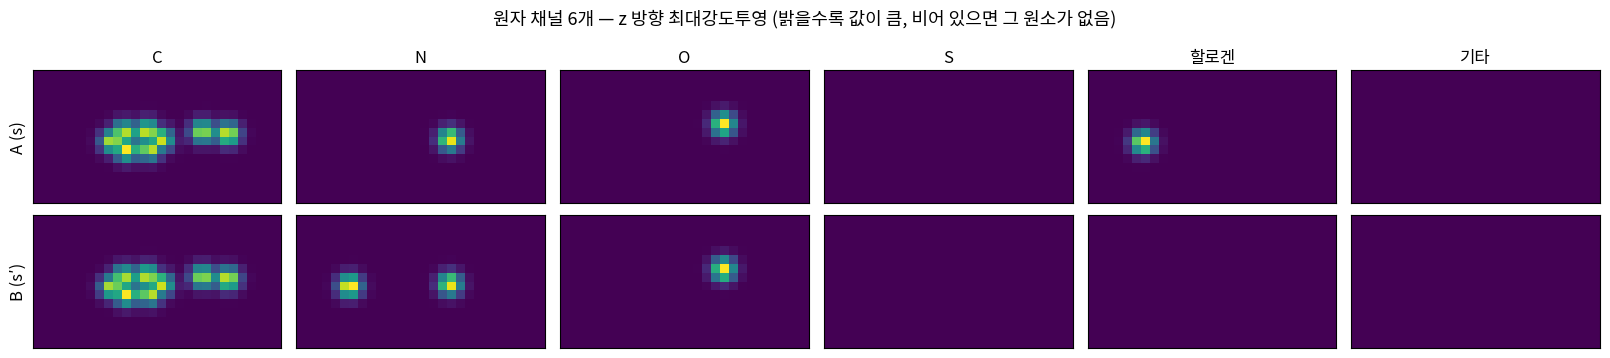

In [14]:
lo = center - BOX_A / 2
EXTENT = [lo[0], lo[0] + BOX_A, lo[1], lo[1] + BOX_A]              # 그림 좌표 = 실제 Å
xy_lo, xy_hi = both[:, :2].min(0) - 3, both[:, :2].max(0) + 3     # 분자 주변만 확대
ASPECT = (xy_hi[1] - xy_lo[1]) / (xy_hi[0] - xy_lo[0])            # 그림 세로/가로 비

def show_mip(grids, names, row_labels, cmap="viridis", suptitle=""):
    """grids: [(채널, N, N, N), ...] — 행마다 한 분자, 열마다 한 채널"""
    nr, nc = len(grids), len(names)
    fig, axes = plt.subplots(nr, nc, figsize=(2.7 * nc, 2.7 * ASPECT * nr + 0.9), squeeze=False)
    for c in range(nc):
        vmax = max(max(float(g[c].max()) for g in grids), 1e-6)    # 같은 채널은 같은 색 범위
        for r, g in enumerate(grids):
            ax = axes[r, c]
            ax.imshow(g[c].max(axis=2).T, origin="lower", extent=EXTENT, cmap=cmap, vmin=0, vmax=vmax)
            ax.set_xlim(xy_lo[0], xy_hi[0]); ax.set_ylim(xy_lo[1], xy_hi[1])
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(names[c])
            if c == 0: ax.set_ylabel(row_labels[r], fontsize=12)
    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout(); plt.show()

show_mip([atoms_s, atoms_sp], ATOM_CHANNELS, ["A (s)", "B (s′)"],
         suptitle="원자 채널 6개 — z 방향 최대강도투영 (밝을수록 값이 큼, 비어 있으면 그 원소가 없음)")

## 7. 결합 채널 4개 (단일, 이중, 삼중, 방향족)

- 결합은 두 원자를 잇는 **선분**이다. 각 칸에서 선분까지의 최단거리 d 를 구해 exp(−d² / 2σ²), σ = 0.30 Å 로 칠한다 → 양 끝이 둥근 막대(캡슐).
  - 선분 위 가장 가까운 점: t = clip( (x − p₁)·(p₂ − p₁) / |p₂ − p₁|², 0, 1 ),  closest = p₁ + t (p₂ − p₁)
  - σ 를 원자(0.45)보다 작게 해서 **원자 = 공, 결합 = 가는 막대**로 구분되게 했다.
- 결합 종류별로 채널을 나눈다 (`voxelize_mmp.py:62` `bond_channel`). 벤젠 고리의 결합은 단일/이중이 아니라 '방향족' 채널로 간다.
- 원자 채널이 **node(구조)**, 결합 채널이 **edge(연결)** 정보를 맡는다 — 분자 그래프를 격자 위에 그린 것과 같다.

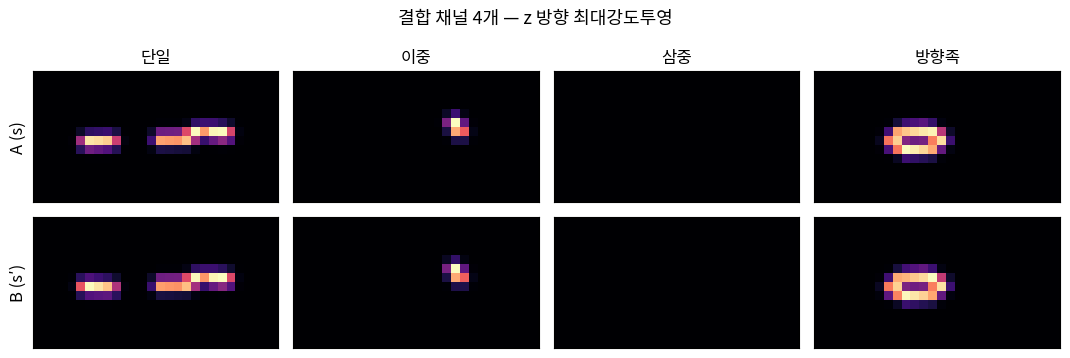

In [15]:
BOND_CHANNELS = ["단일", "이중", "삼중", "방향족"]
SIGMA_BOND = 0.30

def bond_channel(bond):
    if bond.GetIsAromatic():
        return 3
    order = bond.GetBondTypeAsDouble()
    return 2 if order >= 3.0 else 1 if order >= 2.0 else 0

def bond_grid(mol, combine="max"):
    pos = positions(mol)
    g = np.zeros((4, N, N, N), np.float32)
    for bond in mol.GetBonds():
        p1, p2 = pos[bond.GetBeginAtomIdx()], pos[bond.GetEndAtomIdx()]
        d = p2 - p1
        t = np.clip(((pts - p1) @ d) / float(d @ d), 0.0, 1.0)    # 선분 위 가장 가까운 점 (0 = p1, 1 = p2)
        dist2 = ((pts - (p1 + t[..., None] * d)) ** 2).sum(-1)
        val = np.exp(-dist2 / (2 * SIGMA_BOND**2))
        ch = g[bond_channel(bond)]
        if combine == "max":
            np.maximum(ch, val, out=ch)      # 원본 방식
        else:
            ch += val                        # 비교용 (7-2 에서 사용)
    return g

bonds_s, bonds_sp = bond_grid(a3), bond_grid(b3)
show_mip([bonds_s, bonds_sp], BOND_CHANNELS, ["A (s)", "B (s′)"], cmap="magma",
         suptitle="결합 채널 4개 — z 방향 최대강도투영")

### 7-2. 왜 결합은 합(sum)이 아니라 최댓값(max)으로 합치나

원자 하나에는 결합이 2–3개 모인다. 같은 채널의 결합을 **더하면** 그 원자 자리 값이 2–3배가 되어 결합 막대가 원자 공보다 굵어지고 원자를 덮어 버린다 (`docs/입력구조_v2.md` 2절, 첫 렌더에서 확인된 문제). **max** 로 합치면 겹쳐도 1 을 넘지 않는다. 결합이 3개 붙은 원자 자리에서 직접 비교해 본다.

In [16]:
hub = next(a.GetIdx() for a in a3.GetAtoms() if a.GetDegree() == 3)   # 결합 3개 달린 첫 원자
ijk = np.unravel_index(((pts - positions(a3)[hub]) ** 2).sum(-1).argmin(), (N, N, N))
bonds_sum = bond_grid(a3, combine="sum")

print(f"원자 {label(a3, hub)} (결합 {a3.GetAtomWithIdx(hub).GetDegree()}개) 에 가장 가까운 칸의 값")
atom_v = atoms_s[(slice(None),) + ijk].max()
sum_v, max_v = bonds_sum[(slice(None),) + ijk].max(), bonds_s[(slice(None),) + ijk].max()
print(f"  합(sum) : 결합 {sum_v:.2f} vs 원자 {atom_v:.2f}", "→ 결합 막대가 원자 공보다 굵어짐" if sum_v > atom_v else "")
print(f"  max     : 결합 {max_v:.2f} vs 원자 {atom_v:.2f}", "→ 원자 = 공, 결합 = 막대로 구분됨" if max_v < atom_v else "")
pd.DataFrame({"합(sum)": bonds_sum[(slice(None),) + ijk], "최댓값(max, 원본)": bonds_s[(slice(None),) + ijk]},
             index=BOND_CHANNELS).round(2).T

원자 C1 (결합 3개) 에 가장 가까운 칸의 값
  합(sum) : 결합 1.24 vs 원자 0.78 → 결합 막대가 원자 공보다 굵어짐
  max     : 결합 0.68 vs 원자 0.78 → 원자 = 공, 결합 = 막대로 구분됨


,단일,이중,삼중,방향족
합(sum),1.24,0.6,0.0,0.0
"최댓값(max, 원본)",0.68,0.6,0.0,0.0


## 8. ESP 채널 1개 (분자 표면의 정전위)

**ESP (Electrostatic Potential, 정전위)** = 그 자리에 +1 전하를 놓았을 때 느끼는 전기적 에너지. **음(−, 빨강)** 이면 전자가 풍부한 곳(예: 카보닐 O), **양(+, 파랑)** 이면 전자가 부족한 곳(예: N–H 의 H). 단백질과의 수소결합·정전기 상호작용을 좌우한다.

> **왜 따로 넣나** — 한 점의 정전위는 분자 **전체** 원자의 전하를 모두 합해야 나온다. 주변 몇 칸만 보는 CNN 필터가 스스로 만들기 어려워서 미리 계산해 넣는다 (`docs/계획서_2.1_모델설명.md`).

ESP 를 구하는 방법은 두 가지다. 채널에는 **8-2 의 양자화학(DFT) 값**을 쓴다 (`build_voxel_v2.py:133` `esp_channel`, 기본값 `method="qm"`).

| | 8-1 점전하 근사 (MMFF94) | 8-2 양자화학 (DFT) |
|---|---|---|
| 전자 분포 | 원자마다 전하 한 점으로 뭉뚱그림 | 전자 구름 ρ(r) 을 직접 계산 |
| 정전위 | 쿨롱 합 332 · Σ qᵢ / r | 핵 − 전자 구름 적분 (점전하 근사 없음) |
| 시간 (분자 1개) | 1초 미만 | 약 10초 (32코어) |
| 정확도 | 부호·패턴은 맞음, 크기 약 25% 과장 | 기준값 |

### 8-1. 점전하 근사 (MMFF94) — 예전 방식, 비교용

계산 순서 (`build_voxel_v2.py:133` `esp_channel(method="mmff")`)

1. **수소를 다시 붙인다** (`AddHs(addCoords=True)`) — 전하 분포와 분자 표면은 수소까지 포함해야 맞다.
2. **원자별 부분전하 qᵢ** — MMFF94 힘장의 부분전하 (실패하면 Gasteiger).
3. **정전위** φ(x) = 332.06 · Σᵢ qᵢ / |x − rᵢ|  (kcal/mol, 점전하 쿨롱 근사). 원자에 너무 가까우면 발산하므로 거리를 최소 0.5 Å 로 자른다.
4. **표면까지 거리** sdf(x) = minᵢ ( |x − rᵢ| − R_vdW,ᵢ ) — 원자를 vdW 반지름 크기 공으로 보고, 가장 가까운 공 표면까지의 거리. 밖이면 +, 안이면 −, 표면 위면 0.
5. **표면 셸 가중치** w(x) = exp(−sdf² / 2·0.40²) — 표면(sdf = 0) 근처에서만 1 에 가깝고 멀어지면 0.
6. **채널값** = φ(x) · w(x) / 30 — 표면 근처에만 ESP 가 남는다. 30 kcal/mol 로 나눠 다른 채널과 비슷한 크기로 맞춘다 (이 스케일은 원본 문서에 [확인 필요] 로 표시됨).

> **한계** — MMFF94 점전하 ESP 는 양자화학(DFT) 대비 부호·패턴은 잘 맞지만(r ≈ 0.94–0.96) 크기가 약 25% 크다 (`docs/입력구조_v2.md` 3.1절, `src/esp_validate*.py`). 그래서 8-2 에서 DFT 로 다시 구한다.

In [17]:
COULOMB, ESP_SCALE = 332.0637, 30.0

def partial_charges(mol_h):
    props = AllChem.MMFFGetMoleculeProperties(mol_h)
    if props is not None:
        return np.array([props.GetMMFFPartialCharge(i) for i in range(mol_h.GetNumAtoms())]), "MMFF94"
    AllChem.ComputeGasteigerCharges(mol_h)
    return np.array([a.GetDoubleProp("_GasteigerCharge") for a in mol_h.GetAtoms()]), "Gasteiger"

a3_h = Chem.AddHs(a3, addCoords=True)                  # 1. 수소 붙이기
q_a, charge_model = partial_charges(a3_h)              # 2. 부분전하
print(f"분자 A: 수소 포함 원자 {a3_h.GetNumAtoms()}개, 전하 모델 {charge_model}, "
      f"전하 합 {q_a.sum():+.3f} (중성 분자라 0)")
print("부분전하 qᵢ (음수 = 전자가 몰린 원자)")
pd.DataFrame({"q": q_a}, index=[label(a3_h, i) for i in range(a3_h.GetNumAtoms())]).round(3).T

분자 A: 수소 포함 원자 19개, 전하 모델 MMFF94, 전하 합 -0.000 (중성 분자라 0)
부분전하 qᵢ (음수 = 전자가 몰린 원자)


,C0,C1,O2,N3,C4,C5,C6,C7,F8,C9,C10,H11,H12,H13,H14,H15,H16,H17,H18
q,0.061,0.569,-0.57,-0.547,0.117,-0.15,-0.15,0.19,-0.19,-0.15,-0.15,0.0,0.0,0.0,0.37,0.15,0.15,0.15,0.15


In [18]:
def esp_channel_mmff(mol):
    mol_h = Chem.AddHs(mol, addCoords=True)
    q, cm = partial_charges(mol_h)
    pos = positions(mol_h)
    pt = Chem.GetPeriodicTable()
    r_vdw = np.array([pt.GetRvdw(a.GetAtomicNum()) for a in mol_h.GetAtoms()])

    flat = pts.reshape(-1, 3)
    d = np.linalg.norm(flat[:, None, :] - pos[None, :, :], axis=-1)   # (칸 수, 원자 수) 거리표
    sdf = (d - r_vdw).min(1)                                          # 4. 표면까지 거리
    phi = COULOMB * (q / np.maximum(d, 0.5)).sum(1)                   # 3. 정전위
    shell = np.exp(-sdf**2 / (2 * SIGMA_SURF**2))                     # 5. 셸 가중치
    esp = phi * shell / ESP_SCALE                                     # 6. 채널값
    r3 = lambda v: v.reshape(N, N, N).astype(np.float32)
    return r3(esp), r3(sdf), r3(phi), shell.reshape(N, N, N), cm

esp_mm_s, sdf_s, phi_mm_s, shell_s, _ = esp_channel_mmff(a3)
esp_mm_sp, sdf_sp, phi_mm_sp, shell_sp, _ = esp_channel_mmff(b3)

surf_s, surf_sp = np.abs(sdf_s) < RES_A / 2, np.abs(sdf_sp) < RES_A / 2     # 표면 위 칸
print(f"[MMFF] 표면 ESP 범위    s [{phi_mm_s[surf_s].min():6.1f}, {phi_mm_s[surf_s].max():6.1f}]   "
      f"s′ [{phi_mm_sp[surf_sp].min():6.1f}, {phi_mm_sp[surf_sp].max():6.1f}] kcal/mol")
print(f"[MMFF] ESP 채널값 범위  s [{esp_mm_s.min():.2f}, {esp_mm_s.max():.2f}]   s′ [{esp_mm_sp.min():.2f}, {esp_mm_sp.max():.2f}]")

[MMFF] 표면 ESP 범위    s [ -72.8,   76.5]   s′ [ -75.9,   72.3] kcal/mol
[MMFF] ESP 채널값 범위  s [-2.00, 2.18]   s′ [-2.09, 2.06]


3–6번이 격자에서 어떻게 보이는지, 분자 A 를 한 높이(z)에서 **잘라낸 단면**으로 확인한다. 검은 선 = vdW 표면(sdf = 0), 검은 점 = 단면 근처 원자.
- ② 정전위 φ 는 분자 안팎 어디에나 값이 있지만, ③ 셸 가중치를 곱하면 ④ 처럼 **표면(검은 선) 근처 얇은 띠에만** 남는다.

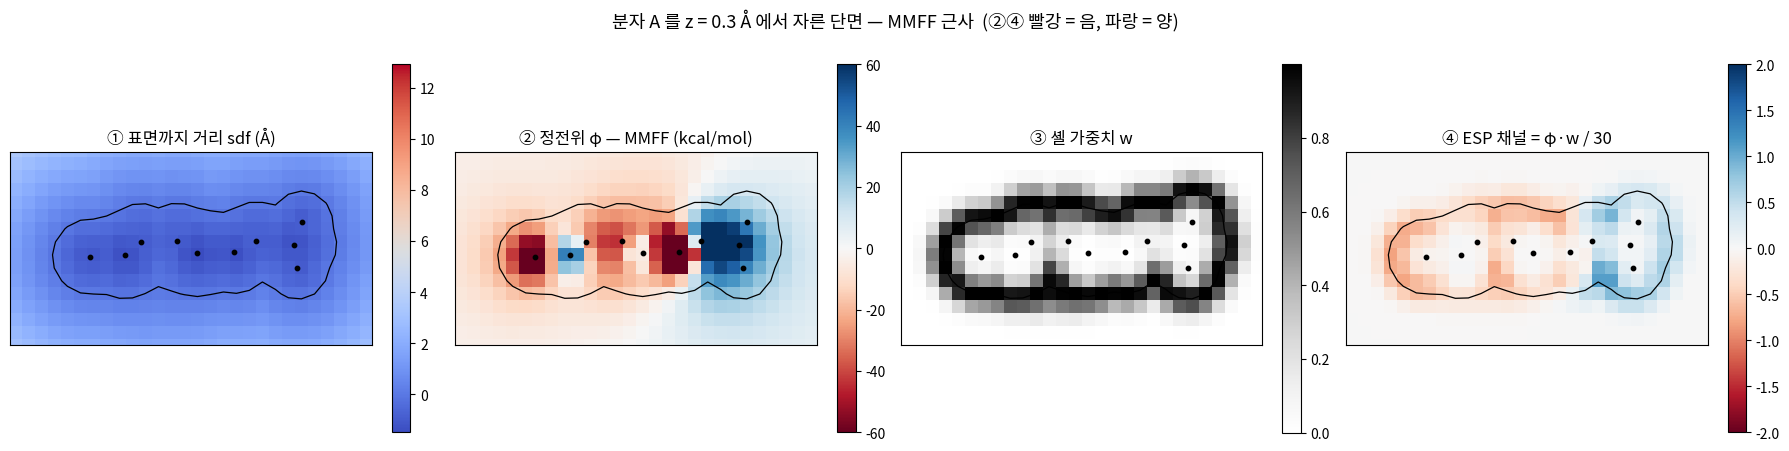

In [19]:
k0 = int(np.clip(np.round((pa[:, 2].mean() - pts[0, 0, 0, 2]) / RES_A), 0, N - 1))   # 분자 A 평균 높이의 칸
z0 = pts[0, 0, k0, 2]
pos_h = positions(a3_h)
near = pos_h[np.abs(pos_h[:, 2] - z0) < 1.0]

panels = [("① 표면까지 거리 sdf (Å)", sdf_s, "coolwarm", None),
          ("② 정전위 φ — MMFF (kcal/mol)", phi_mm_s, "RdBu", 60),
          ("③ 셸 가중치 w", shell_s, "Greys", None),
          ("④ ESP 채널 = φ·w / 30", esp_mm_s, "RdBu", 2)]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, (title, vol, cmap, v) in zip(axes, panels):
    im = ax.imshow(vol[:, :, k0].T, origin="lower", extent=EXTENT, cmap=cmap,
                   **({"vmin": -v, "vmax": v} if v else {}))
    ax.contour(pts[:, :, k0, 0], pts[:, :, k0, 1], sdf_s[:, :, k0], levels=[0], colors="k", linewidths=0.9)
    ax.scatter(near[:, 0], near[:, 1], s=10, c="k")
    ax.set_xlim(xy_lo[0], xy_hi[0]); ax.set_ylim(xy_lo[1], xy_hi[1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"분자 A 를 z = {z0:.1f} Å 에서 자른 단면 — MMFF 근사  (②④ 빨강 = 음, 파랑 = 양)", fontsize=13)
fig.tight_layout(); plt.show()

### 8-2. 양자화학(DFT)으로 구하기 — 채널에 쓰는 방식

점전하 근사 대신 **전자 구름 자체**를 계산해서 정전위를 구한다 (`src/qm_esp.py`, `build_voxel_v2.py:133` `esp_channel(method="qm")`). 8-1 의 1·4·5·6 단계(수소 붙이기, 표면 거리, 셸 가중치, 채널값)는 그대로이고 **2·3 단계(전하 → 정전위)만 바뀐다.**

**① DFT 로 전자밀도 구하기**
- 분자의 전자 분포를 슈뢰딩거 방정식의 근사해로 구한다. 계산 수준은 **B3LYP / 6-31G(d)** — B3LYP 는 범함수(전자끼리의 상호작용을 다루는 방식), 6-31G(d) 는 기저함수(전자 구름을 표현하는 함수 묶음)다. `esp_validate.py` 의 기준 계산과 같은 수준이다.
- SCF (Self-Consistent Field) 반복이 수렴하면 **밀도행렬 D** 가 나온다. 전자밀도는 ρ(r) = Σ_μν D_μν χ_μ(r) χ_ν(r)  (χ = 기저함수).
- `density_fit()` 은 계산을 빠르게 하는 근사(density fitting)로, 결과에 주는 영향은 매우 작다.
- 검산: 전자밀도를 공간 전체에서 적분하면 전자 수가 나와야 한다 → Σ D·S (S = 기저함수 겹침 행렬) = 전자 수.

In [20]:
import time
from pyscf import df, dft, gto, lib
from scipy.spatial.distance import cdist

lib.num_threads(min(32, os.cpu_count()))       # 공용 서버라 32코어까지만 사용
BOHR, HARTREE_KCAL = 0.529177210903, 627.509474   # PySCF 는 원자 단위 (길이 bohr, 에너지 hartree)

def run_dft(mol_h):
    conf = mol_h.GetConformer()
    atoms = [(a.GetSymbol(), tuple(conf.GetAtomPosition(i))) for i, a in enumerate(mol_h.GetAtoms())]
    qmol = gto.M(atom=atoms, basis="6-31g*", unit="Angstrom",
                 charge=Chem.GetFormalCharge(mol_h), spin=0, verbose=0)
    mf = dft.RKS(qmol, xc="b3lyp").density_fit()
    mf.max_memory = 6000
    mf.kernel()                                  # SCF 반복
    return qmol, mf

t0 = time.time()
qmol_a, mf_a = run_dft(a3_h)                     # 8-1 에서 만든 수소 포함 분자 A
dm_a = mf_a.make_rdm1()                          # 밀도행렬 D
n_elec = np.einsum("ij,ji->", dm_a, qmol_a.intor("int1e_ovlp"))   # Σ D·S
print(f"분자 A: 원자 {qmol_a.natm}개, 기저함수 {qmol_a.nao}개, SCF 수렴 {mf_a.converged}, {time.time() - t0:.1f}초")
print(f"전체 에너지 {mf_a.e_tot:.4f} hartree")
print(f"밀도행렬 D {dm_a.shape},  검산 Σ D·S = {n_elec:.4f}  (실제 전자 수 {qmol_a.nelectron})")

분자 A: 원자 19개, 기저함수 170개, SCF 수렴 True, 21.1초
전체 에너지 -539.4854 hartree
밀도행렬 D (170, 170),  검산 Σ D·S = 80.0000  (실제 전자 수 80)


**② 정전위 적분**

  V(r) = Σ_A Z_A / |r − R_A|  −  ∫ ρ(r′) / |r − r′| dr′

- 첫 항 = **핵**(양전하 Z_A)이 만드는 전위, 둘째 항 = **전자 구름**(음전하)이 만드는 전위. 점전하 근사와 달리 전자 구름의 실제 모양이 들어간다.
- 둘째 항: 격자 점마다 "단위 점전하"를 놓고, 그 점전하와 기저함수 쌍 χ_μχ_ν 사이의 적분을 구해 D 와 곱해 더한다. PySCF 에서는 격자 점들을 가짜 분자(`fakemol_for_charges`)로 만들어 3중심 적분(`aux_e2`)으로 한 번에 계산한다.
- 단위 변환: 1 bohr = 0.529 Å, 1 hartree = 627.5 kcal/mol.
- **표면 셸 근처 칸(셸 가중치 > 10⁻⁴)만 계산한다.** 나머지 칸은 어차피 채널값이 0 에 가깝다 → 전체의 약 5% 만 계산하면 된다.

In [21]:
SHELL_MIN = 1e-4

def esp_at(qmol, dm, pts_a, chunk=256):
    """정전위 V(r) (kcal/mol) = 핵 기여 − 전자 기여.  pts_a: Å 좌표 (n, 3)"""
    pts_b = pts_a / BOHR                                                      # Å → bohr
    v_nuc = (qmol.atom_charges() / cdist(pts_b, qmol.atom_coords())).sum(1)   # Σ Z_A / |r − R_A|
    v_ele = np.empty(len(pts_b))
    for s in range(0, len(pts_b), chunk):
        fake = gto.fakemol_for_charges(pts_b[s:s + chunk])                   # 격자 점 = 단위 점전하
        v_ele[s:s + chunk] = np.einsum("ijp,ij->p", df.incore.aux_e2(qmol, fake), dm)   # ∫ ρ / |r − r′|
    return (v_nuc - v_ele) * HARTREE_KCAL                                     # hartree → kcal/mol

def esp_channel_qm(mol, shell, dft_result=None):
    qmol, mf = dft_result or run_dft(Chem.AddHs(mol, addCoords=True))
    near = shell.ravel() > SHELL_MIN                                          # 표면 셸 근처 칸만
    phi = np.zeros(N**3)
    phi[near] = esp_at(qmol, mf.make_rdm1(), pts.reshape(-1, 3)[near])
    esp = phi * shell.ravel() / ESP_SCALE                                     # 채널값 (8-1 의 6번과 같은 식)
    r3 = lambda v: v.reshape(N, N, N).astype(np.float32)
    return r3(esp), r3(phi), int(near.sum())

t0 = time.time()
esp_qm_s, phi_qm_s, n_pts = esp_channel_qm(a3, shell_s, (qmol_a, mf_a))   # A 는 위의 DFT 결과 재사용
esp_qm_sp, phi_qm_sp, _ = esp_channel_qm(b3, shell_sp)                     # B 는 DFT 부터
print(f"계산한 칸 {n_pts:,} / {N**3:,} ({n_pts / N**3:.1%}),  A 의 ESP + B 의 DFT·ESP {time.time() - t0:.1f}초")
print(f"[DFT ] 표면 ESP 범위   s [{phi_qm_s[surf_s].min():6.1f}, {phi_qm_s[surf_s].max():6.1f}]   "
      f"s′ [{phi_qm_sp[surf_sp].min():6.1f}, {phi_qm_sp[surf_sp].max():6.1f}] kcal/mol")
print(f"[MMFF] 표면 ESP 범위   s [{phi_mm_s[surf_s].min():6.1f}, {phi_mm_s[surf_s].max():6.1f}]   "
      f"s′ [{phi_mm_sp[surf_sp].min():6.1f}, {phi_mm_sp[surf_sp].max():6.1f}] kcal/mol")

계산한 칸 4,834 / 110,592 (4.4%),  A 의 ESP + B 의 DFT·ESP 24.2초
[DFT ] 표면 ESP 범위   s [ -48.6,   74.4]   s′ [ -54.4,   65.7] kcal/mol
[MMFF] 표면 ESP 범위   s [ -72.8,   76.5]   s′ [ -75.9,   72.3] kcal/mol


**③ 두 방법 비교** — 8-1 과 같은 단면에서 MMFF 채널, DFT 채널, 둘의 차이를 보고, 오른쪽에서 표면 칸의 φ 를 점으로 비교한다.

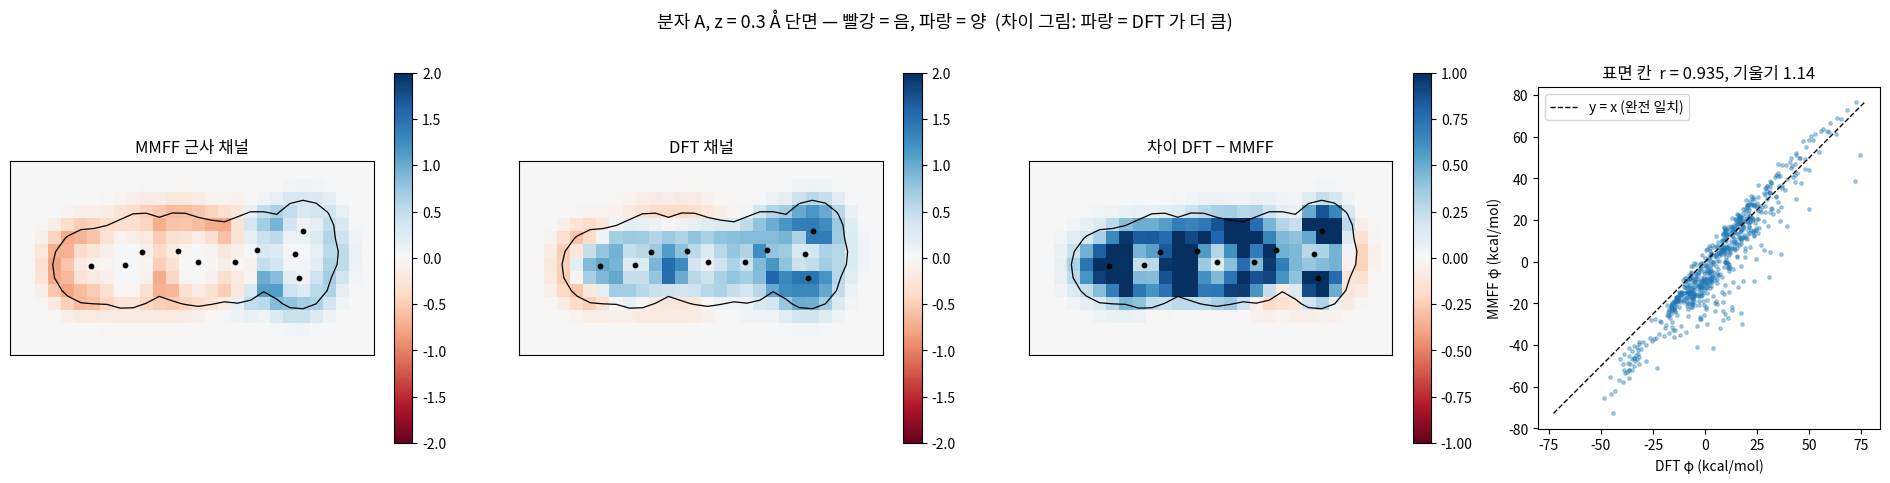

In [22]:
x, y = phi_qm_s[surf_s], phi_mm_s[surf_s]
r, slope = np.corrcoef(x, y)[0, 1], np.polyfit(x, y, 1)[0]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), gridspec_kw={"width_ratios": [1, 1, 1, 0.85]})
for ax, (title, vol, v) in zip(axes[:3], [("MMFF 근사 채널", esp_mm_s, 2), ("DFT 채널", esp_qm_s, 2),
                                         ("차이 DFT − MMFF", esp_qm_s - esp_mm_s, 1)]):
    im = ax.imshow(vol[:, :, k0].T, origin="lower", extent=EXTENT, cmap="RdBu", vmin=-v, vmax=v)
    ax.contour(pts[:, :, k0, 0], pts[:, :, k0, 1], sdf_s[:, :, k0], levels=[0], colors="k", linewidths=0.9)
    ax.scatter(near[:, 0], near[:, 1], s=10, c="k")
    ax.set_xlim(xy_lo[0], xy_hi[0]); ax.set_ylim(xy_lo[1], xy_hi[1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
ax = axes[3]
ax.scatter(x, y, s=6, alpha=0.35)
lim = np.array([min(x.min(), y.min()), max(x.max(), y.max())])
ax.plot(lim, lim, "k--", lw=1, label="y = x (완전 일치)")
ax.set_xlabel("DFT φ (kcal/mol)"); ax.set_ylabel("MMFF φ (kcal/mol)")
ax.set_title(f"표면 칸  r = {r:.3f}, 기울기 {slope:.2f}"); ax.legend(loc="upper left")
ax.set_aspect("equal")
fig.suptitle(f"분자 A, z = {z0:.1f} Å 단면 — 빨강 = 음, 파랑 = 양  (차이 그림: 파랑 = DFT 가 더 큼)", fontsize=13)
fig.tight_layout(); plt.show()

**읽는 법**
- 빨강/파랑이 놓인 위치(부호·패턴)는 두 방법이 거의 같다 → 산점도의 상관계수 r.
- 기울기가 1 보다 크면 MMFF 가 크기를 부풀린다는 뜻이다. 차이 그림에서 파랑(DFT 가 더 큼)이 음(빨강) 영역 위에 있으면, MMFF 가 음전위를 더 깊게 과장한 것이다 (`docs/입력구조_v2.md` 3.1절 부위별 표: 방향족 고리 면·N·O 주변 과장).

**④ 핵 근처 점검** — 실제 ESP 는 핵에 가까워질수록 핵의 양전하 때문에 매우 커진다 (점전하 근사는 거리를 0.5 Å 에서 잘라서 이런 값이 없었다). 표면에서 안쪽으로 들어가며 구간별로 확인한다. 셸 가중치가 안쪽으로 갈수록 빠르게 줄어서, 채널값이 표면 구간보다 커지지 않는지가 핵심이다.

In [23]:
bands = [("밖 (0.25 이상)", 0.25, 99), ("표면 (−0.25 ~ 0.25)", -0.25, 0.25), ("안쪽 (−0.5 ~ −0.25)", -0.5, -0.25),
         ("안쪽 (−1 ~ −0.5)", -1.0, -0.5), ("핵 근처 (−1 미만)", -99, -1.0)]
rows = []
for name, lo_, hi_ in bands:
    s = (sdf_s >= lo_) & (sdf_s < hi_) & (shell_s > SHELL_MIN)
    rows.append((name, int(s.sum()), phi_qm_s[s].max(), np.abs(esp_qm_s[s]).max(), np.abs(esp_mm_s[s]).max()))
pd.DataFrame(rows, columns=["sdf 구간 (Å)", "칸 수", "DFT φ 최대 (kcal/mol)", "|DFT 채널| 최대", "|MMFF 채널| 최대"]
             ).set_index("sdf 구간 (Å)").astype(float).round(2)

,칸 수,DFT φ 최대 (kcal/mol),|DFT 채널| 최대,|MMFF 채널| 최대
sdf 구간 (Å),,,,
밖 (0.25 이상),3368.0,39.22,1.06,1.26
표면 (−0.25 ~ 0.25),698.0,74.38,2.17,2.18
안쪽 (−0.5 ~ −0.25),277.0,115.33,2.08,2.03
안쪽 (−1 ~ −0.5),379.0,789.19,1.90,1.67
핵 근처 (−1 미만),112.0,11645.61,1.10,0.34


In [24]:
esp_s, esp_sp = esp_qm_s, esp_qm_sp     # 10단계부터 채널에는 DFT ESP 를 쓴다 (build_voxel_v2.py 기본값과 같음)
print("ESP 채널 = DFT (B3LYP/6-31G*)")

ESP 채널 = DFT (B3LYP/6-31G*)


## 9. 편집 종류 a 판정 (Replace / Insert / Delete)

MCS 밖 원자가 곧 편집 부위다. **lost** = A 에서 MCS 밖 원자 수(사라진 것), **gained** = B 에서 MCS 밖 원자 수(생긴 것).

| 조건 | a | 예시 쌍 |
|---|---|---|
| lost > 0, gained > 0 | Replace | 01 F → NH₂, 02 피롤리딘 → 피페리딘 |
| lost = 0, gained > 0 | Insert | 03 H → 페닐 |
| lost > 0, gained = 0 | Delete | 04 OMe → H |

모델에는 **3칸 one-hot 벡터**로 들어간다: Replace = [1, 0, 0], Insert = [0, 1, 0], Delete = [0, 0, 1]. 이 벡터는 3D CNN 을 거치지 않고 결합 벡터에 바로 붙는다 (계획서의 AC-aware ① "표현에 넣기").

In [25]:
ACTIONS = ["Replace", "Insert", "Delete"]

def action_type(n_lost, n_gained):
    if n_lost and n_gained:
        return "Replace"
    if n_gained:
        return "Insert"
    if n_lost:
        return "Delete"
    raise ValueError("A 와 B 가 MCS 기준으로 같음")

lost = [i for i in range(a3.GetNumAtoms()) if i not in set(ma)]
gained = [i for i in range(b3.GetNumAtoms()) if i not in set(mb)]
act = action_type(len(lost), len(gained))
action_onehot = np.array([a == act for a in ACTIONS], np.float32)

print("A 에서 사라진 원자 (lost)  :", [label(a3, i) for i in lost])
print("B 에 생긴 원자   (gained)  :", [label(b3, i) for i in gained])
print(f"편집 종류 a = {act}   → one-hot {action_onehot}  (순서 {ACTIONS})")

A 에서 사라진 원자 (lost)  : ['F8']
B 에 생긴 원자   (gained)  : ['N8']
편집 종류 a = Replace   → one-hot [1. 0. 0.]  (순서 ['Replace', 'Insert', 'Delete'])


## 10. 모델 입력 조립 — (X_s, X_s′, a)

- 원자 6 + 결합 4 + ESP 1 = **11채널**을 쌓는다 → X ∈ ℝ^(11×48×48×48). 딥러닝에서 쓰는 3D 이미지(채널 × 깊이 × 높이 × 너비)와 같은 모양이라 3D CNN 에 그대로 넣을 수 있다.
- 라벨 ΔpKi = pKi(B) − pKi(A) 는 **실측값이 아직 연결되지 않아 NaN** 으로 둔다. 원본도 `delta_pki=np.nan` 으로 두고 값을 만들지 않는다.

In [26]:
CHANNELS = ATOM_CHANNELS + BOND_CHANNELS + ["ESP"]
X_s = np.concatenate([atoms_s, bonds_s, esp_s[None]])
X_sp = np.concatenate([atoms_sp, bonds_sp, esp_sp[None]])
delta_pki = np.nan

print(f"X_s   {X_s.shape}  {X_s.dtype}  {X_s.nbytes / 1e6:.1f} MB")
print(f"X_s′  {X_sp.shape}  {X_sp.dtype}  {X_sp.nbytes / 1e6:.1f} MB")
print(f"a     {act} → {action_onehot}")
print(f"ΔpKi  {delta_pki}  (라벨 미연결)")

pd.DataFrame({
    "s 최솟값": X_s.reshape(11, -1).min(1),
    "s 최댓값": X_s.reshape(11, -1).max(1),
    "s′ 최솟값": X_sp.reshape(11, -1).min(1),
    "s′ 최댓값": X_sp.reshape(11, -1).max(1),
    "Σ|s′ − s| (바뀐 양)": np.abs(X_sp - X_s).reshape(11, -1).sum(1),
}, index=CHANNELS).astype(float).round(2)

X_s   (11, 48, 48, 48)  float32  4.9 MB
X_s′  (11, 48, 48, 48)  float32  4.9 MB
a     Replace → [1. 0. 0.]
ΔpKi  nan  (라벨 미연결)


,s 최솟값,s 최댓값,s′ 최솟값,s′ 최댓값,Σ|s′ − s| (바뀐 양)
C,0.00,0.99,0.0,0.98,2.45
N,0.00,0.85,0.0,0.88,11.61
O,0.00,0.96,0.0,0.96,0.52
S,0.00,0.00,0.0,0.00,0.00
할로겐,0.00,0.92,0.0,0.00,11.48
기타,0.00,0.00,0.0,0.00,0.00
단일,0.00,0.96,0.0,0.96,1.51
이중,0.00,0.91,0.0,0.92,0.36
삼중,0.00,0.00,0.0,0.00,0.00
방향족,0.00,0.94,0.0,0.94,1.65


두 입력의 **차이 X_s′ − X_s** 를 채널별로 본다 (빨강 = B 에서 생김, 파랑 = A 에서 사라짐). 차이가 편집 부위 근처에만 모여 있으면 정렬이 잘 된 것이고, 골격 쪽에 흩어져 있으면 conformer 차이(노이즈)다.

v2 는 이 차이(ΔV)를 직접 입력으로 넣지 않는다. 대신 X_s 와 X_s′ 를 **같은 인코더**(siamese)에 넣고, 모델 안에서 특징 차이 z′ − z 로 배우게 한다 (`docs/입력구조_v2.md` 1절).

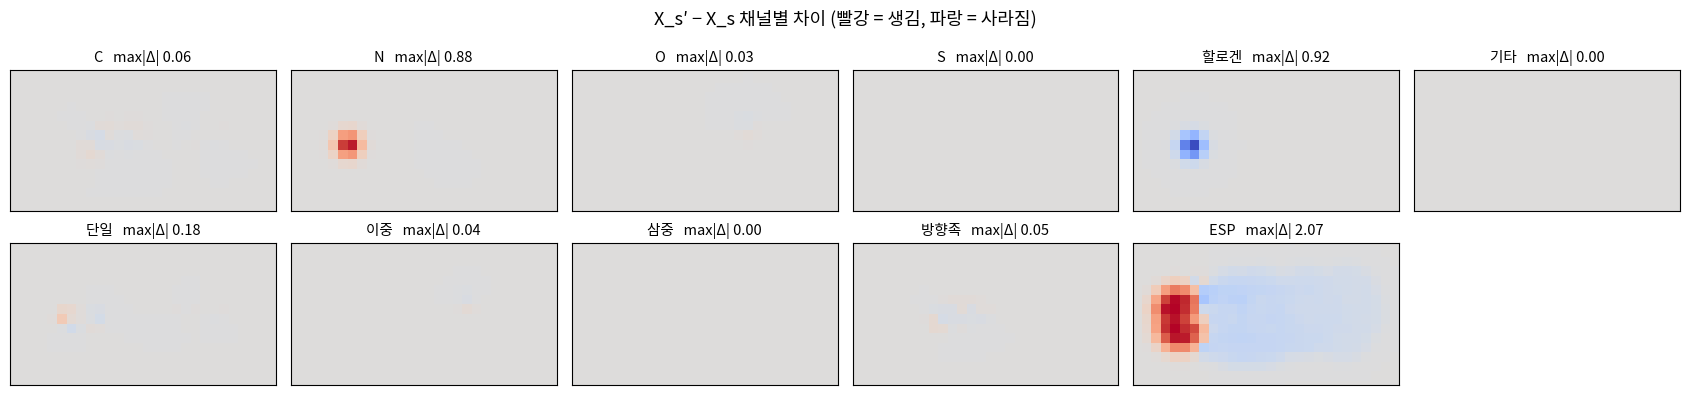

In [27]:
delta = X_sp - X_s
v_base = max(float(np.abs(delta[:10]).max()), 1e-6)       # 원자·결합 채널은 같은 색 범위
fig, axes = plt.subplots(2, 6, figsize=(17, 2 * 2.8 * ASPECT + 1.2))
for c, ax in enumerate(axes.flat):
    if c >= 11:
        ax.axis("off"); continue
    k = np.abs(delta[c]).argmax(axis=2)
    img = np.take_along_axis(delta[c], k[..., None], axis=2)[..., 0].T     # 부호를 살린 최대강도투영
    v = v_base if c < 10 else max(float(np.abs(img).max()), 1e-6)
    ax.imshow(img, origin="lower", extent=EXTENT, cmap="coolwarm", vmin=-v, vmax=v)
    ax.set_xlim(xy_lo[0], xy_hi[0]); ax.set_ylim(xy_lo[1], xy_hi[1])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{CHANNELS[c]}   max|Δ| {np.abs(delta[c]).max():.2f}", fontsize=10.5)
fig.suptitle("X_s′ − X_s 채널별 차이 (빨강 = 생김, 파랑 = 사라짐)", fontsize=13)
fig.tight_layout(); plt.show()

**읽는 법**
- 원자·결합 채널의 차이는 **편집 부위 한 곳에만** 모인다 (`01_F_to_NH2` 라면 할로겐 채널 파랑 = F 사라짐, N 채널 빨강 = N 생김). 골격 쪽의 옅은 얼룩은 A 와 B 의 conformer 가 아주 조금 달라서 생긴 작은 차이다.
- ESP 채널에서 색은 '생김/사라짐'이 아니라 **ESP 가 커짐(빨강) / 작아짐(파랑)** 이다.
- ESP 차이는 편집 부위뿐 아니라 **분자 표면 전체로 퍼진다** (위 표의 Σ|s′ − s| 도 ESP 가 가장 크다). 한 점의 정전위가 분자 전체 전하의 합이라서, 치환기 하나만 바뀌어도 표면 전체 값이 조금씩 달라진다. 원자·결합 채널만으로는 드러나지 않는 이 비국소(non-local) 효과를 ESP 채널이 따로 전해 준다.

## 11. 3D 렌더링 (`render_v2.py` 방식)

- 격자에서 값이 0.5 인 점들을 이은 **등가면(isosurface)** 을 채널마다 따로 뽑아 색칠한다 — 원자 = 원소색 공, 결합 = 결합 종류색 막대.
- ESP 는 vdW 표면(sdf = 0)을 뽑고, 그 위에 ESP 채널 값을 칠한다 (빨강 = 음, 파랑 = 양).
- 편집 부위(MCS 밖 원자)는 노란 반투명 껍질로 표시한다.
- 표시할 때만 48³ 을 3배 cubic 보간해 면을 매끄럽게 한다. **모델 입력은 원본 48³ 그대로다.**
- PyVista(VTK)로 화면 없이(off-screen) 그린 뒤 이미지로 보여준다.
- ESP 는 8-2 의 DFT 값이다. 예전 MMFF 방식에서는 방향족 고리 면이 양자화학 값의 2배 이상 진한 빨강으로 과장되어 보였다 (`docs/입력구조_v2.md` 3.1절).

In [28]:
import pyvista as pv
from vtkmodules.vtkCommonCore import vtkLogger   # `import vtk` 전체를 부르면 VTK-m 가속 필터가 contour 를 가로채 커널이 죽음
from scipy import ndimage
from matplotlib.patches import Patch

vtkLogger.SetStderrVerbosity(vtkLogger.VERBOSITY_OFF)   # 화면 없는 서버에서 나오는 VTK 경고 로그 숨김

ATOM_COLORS = ["#474747", "#2F5BEA", "#E0262B", "#E3B505", "#1F9E4A", "#9B4DCA"]
BOND_COLORS = ["#BDBDBD", "#F08A24", "#8E6BD8", "#35A7A0"]
EDIT_COLOR, ISO, UP, WIN = "#FFB000", 0.5, 3, (900, 570)
origin = center - BOX_A / 2 + RES_A / 2          # 첫 칸 중심 좌표

def to_vtk(vol, name="v", up=UP):
    """48³ 배열 → PyVista 격자. 표시용으로만 up 배 cubic 보간."""
    if up > 1:
        vol = ndimage.zoom(vol, up, order=3)
    m = vol.shape[0]
    g = pv.ImageData(dimensions=(m, m, m), spacing=(RES_A * (N - 1) / (m - 1),) * 3, origin=tuple(origin))
    g.point_data[name] = vol.ravel(order="F")     # VTK 는 x 가 가장 빠르게 변하는 순서
    return g

def iso(vol, level=ISO):
    if float(vol.max()) <= level:
        return None
    s = to_vtk(vol).contour([level], scalars="v")
    return s if s.n_points else None

def edit_blob(xyz, sigma=0.8):
    """편집 원자들을 감싸는 매끈한 껍질"""
    if len(xyz) == 0:
        return None
    g = to_vtk(np.zeros((N,) * 3, np.float32), up=2)
    f = np.zeros(g.n_points)
    for c in xyz:
        f += np.exp(-((g.points - c) ** 2).sum(1) / (2 * sigma**2))
    g.point_data["v"] = f
    s = g.contour([0.5], scalars="v")
    return s if s.n_points else None

def add_structure(p, X, edit_xyz):
    shade = dict(smooth_shading=True, specular=0.35, specular_power=25, ambient=0.18)
    for ch in range(10):                                  # 원자 6 + 결합 4, 채널마다 따로 등가면
        s = iso(X[ch])
        if s is not None:
            p.add_mesh(s, color=(ATOM_COLORS + BOND_COLORS)[ch], **shade)
    b = edit_blob(edit_xyz)
    if b is not None:
        p.add_mesh(b, color=EDIT_COLOR, opacity=0.2, smooth_shading=True)

def add_esp(p, X, sdf, clim):
    surf = to_vtk(sdf).contour([0.0], scalars="v")                 # vdW 표면 (sdf = 0)
    surf = surf.sample(to_vtk(X[10] * ESP_SCALE, name="esp"))      # 표면 위 ESP (kcal/mol)
    p.add_mesh(surf, scalars="esp", cmap="RdBu", clim=[-clim, clim],
               smooth_shading=True, specular=0.25, show_scalar_bar=False)

def camera(xyz, aspect):
    """분자 평면을 정면에서 25° 기울여 보는 평행 투영 카메라"""
    c = (xyz.min(0) + xyz.max(0)) / 2
    _, _, vt = np.linalg.svd(xyz - xyz.mean(0))
    e1, e2, e3 = vt                                    # e3 = 분자 평면에 수직인 방향
    t = np.deg2rad(25)
    view, up = np.cos(t) * e3 + np.sin(t) * e2, np.cos(t) * e2 - np.sin(t) * e3
    rel = xyz - c
    half = max(np.abs(rel @ up).max(), np.abs(rel @ e1).max() / aspect) + 3.0
    return dict(position=c + 60 * view, focal=c, up=up, scale=half)

cam = camera(both, WIN[0] / WIN[1])

def shot(build):
    p = pv.Plotter(off_screen=True, window_size=WIN)
    p.set_background("white")
    build(p)
    p.camera_position = [tuple(cam["position"]), tuple(cam["focal"]), tuple(cam["up"])]
    p.enable_parallel_projection()
    p.camera.parallel_scale = cam["scale"]
    p.reset_camera_clipping_range()
    p.enable_depth_peeling()
    p.enable_anti_aliasing("ssaa")
    img = p.screenshot(return_img=True)
    p.close()
    return img

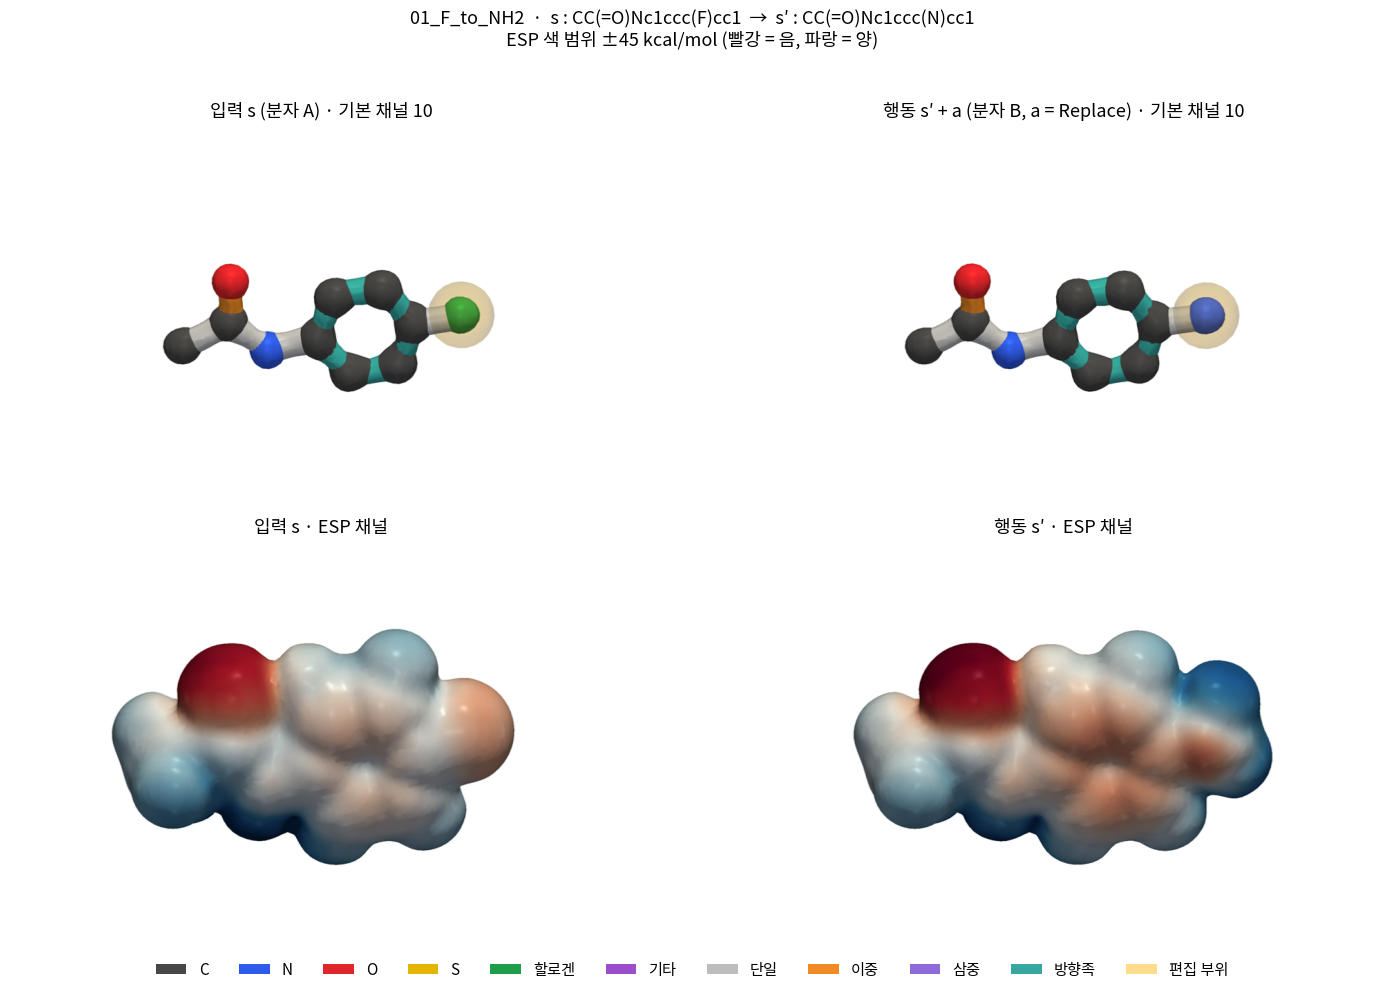

In [29]:
# ESP 색 범위: 표면 위 |ESP| 의 95 백분위를 5 단위로 올림 (render_v2.global_clim 과 같은 규칙, 이 쌍만 대상)
surf_vals = np.concatenate([np.abs(X[10][np.abs(s) < 0.15]) * ESP_SCALE
                            for X, s in ((X_s, sdf_s), (X_sp, sdf_sp))])
clim = float(np.ceil(np.percentile(surf_vals, 95) / 5) * 5)

imgs = {
    "입력 s (분자 A) · 기본 채널 10":      shot(lambda p: add_structure(p, X_s, pa[lost])),
    f"행동 s′ + a (분자 B, a = {act}) · 기본 채널 10": shot(lambda p: add_structure(p, X_sp, pb[gained])),
    "입력 s · ESP 채널":                   shot(lambda p: add_esp(p, X_s, sdf_s, clim)),
    "행동 s′ · ESP 채널":                  shot(lambda p: add_esp(p, X_sp, sdf_sp, clim)),
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (title, img) in zip(axes.flat, imgs.items()):
    ax.imshow(img); ax.set_title(title, fontsize=13); ax.axis("off")
handles = [Patch(fc=c, label=l) for c, l in zip(ATOM_COLORS + BOND_COLORS, ATOM_CHANNELS + BOND_CHANNELS)]
handles.append(Patch(fc=EDIT_COLOR, alpha=0.45, label="편집 부위"))
fig.legend(handles=handles, ncol=11, loc="lower center", frameon=False, fontsize=11)
fig.suptitle(f"{PICK}  ·  s : {smi_a}  →  s′ : {smi_b}\nESP 색 범위 ±{clim:.0f} kcal/mol (빨강 = 음, 파랑 = 양)",
             fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 0.95]); plt.show()

## 12. 원본 코드와 결과 일치 확인

1–10단계에서 풀어 쓴 계산이 원본 `src/build_voxel_v2.py` · `src/voxelize_mmp.py` 와 **완전히 같은 결과**를 내는지 확인한다. 시드가 같으므로 3D 구조부터 격자 값까지 같아야 한다. 원본도 ESP 를 DFT 로 다시 계산하므로 20초쯤 걸린다. (원본 함수만 호출하고 파일은 저장하지 않는다.)

In [30]:
import build_voxel_v2 as v2
from voxelize_mmp import build_aligned_pair

a3_o, b3_o, ma_o, mb_o, _, _, strat_o = build_aligned_pair(smi_a, smi_b)
both_o = np.vstack([v2.positions(a3_o), v2.positions(b3_o)])
c_o = (both_o.min(0) + both_o.max(0)) / 2
X_s_o, *_ = v2.featurize(a3_o, v2.grid_coords(c_o))
X_sp_o, *_ = v2.featurize(b3_o, v2.grid_coords(c_o))
n_lost = a3_o.GetNumAtoms() - len(ma_o)
n_gained = b3_o.GetNumAtoms() - len(mb_o)

print(f"정렬 전략     원본 {strat_o:18s} 노트북 {strategy}")
print(f"격자 중심     최대 차이 {np.abs(c_o - center).max():.2e} Å")
print(f"편집 종류     원본 {v2.action_type(n_lost, n_gained):18s} 노트북 {act}")
print(f"X_s  일치  {np.allclose(X_s_o, X_s, atol=1e-5)}   최대 차이 {np.abs(X_s_o - X_s).max():.2e}")
print(f"X_s′ 일치  {np.allclose(X_sp_o, X_sp, atol=1e-5)}   최대 차이 {np.abs(X_sp_o - X_sp).max():.2e}")

정렬 전략     원본 AlignMol×10        노트북 AlignMol×10
격자 중심     최대 차이 0.00e+00 Å
편집 종류     원본 Replace            노트북 Replace
X_s  일치  True   최대 차이 0.00e+00
X_s′ 일치  True   최대 차이 0.00e+00


## 정리

| 만든 것 | 모양 | 뜻 |
|---|---|---|
| `X_s` | 11 × 48 × 48 × 48 | 분자 A 의 3D 격자 (원자 6 + 결합 4 + ESP 1) |
| `X_sp` | 11 × 48 × 48 × 48 | 분자 B 의 3D 격자 (A 와 같은 격자 위) |
| `action_onehot` | 3 | 편집 종류 a (Replace / Insert / Delete) |
| `delta_pki` | 스칼라 | 라벨 ΔpKi — **아직 NaN** |

**핵심 설계 포인트 다시 보기**
- **MCS 정렬(4단계)** — 골격을 겹쳐야 두 격자의 차이가 편집 부위에 모인다.
- **채널 분리(6–7단계)** — 원소·결합 종류를 채널로 나눠야 "무엇이 바뀌었는지"가 남는다. 결합은 max 로 합쳐 원자와 구분되게 한다.
- **ESP 채널(8단계)** — 분자 전체 전하가 만드는 표면 성질을 미리 계산해 준다. 점전하 근사(MMFF) 대신 **DFT 전자밀도로 구한 실제 ESP** 를 쓴다 (분자당 약 10초).

**아직 없는 것 (원본 문서 기준)**
- 3D CNN 인코더 (siamese) 와 예측 헤드: head([z, z′, z′ − z, onehot(a)]) → ΔpKi
- ChEMBL / MoleculeACE 의 MMP 쌍 실측 pKi 라벨 연결 [확인 필요: 데이터 구축 방식]
- 데이터셋 전체의 DFT ESP 계산 시간 — 분자당 약 10초 × 분자 수 [확인 필요: 데이터셋 규모, A100 GPU 가속(gpu4pyscf) 검토]

**해 볼 것** — 1단계 `PICK` 을 `02_ring5_to_ring6`(고리 확장이 Replace 로 판정되는 이유), `03_H_to_phenyl`(Insert), `04_OMe_to_H`(Delete) 로 바꿔 위에서부터 다시 실행해 본다.